### **$$\text{Laboratory 3. Basic image segmentation techniques}$$**

**Họ và tên :** Trịnh Dương Hoan \
**MSSV :** 22684251

**Library**

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#### **3.1 Image thresholding**

- **Ex. 3.1 Read the images ‘grayShades.jpg’ and ‘grayFlowers.jpg’ as grayscale images. Experiment with
multiple types of thresholding by changing the parameter type and keeping the same threshold value
for each image separately. Display and compare the output images**

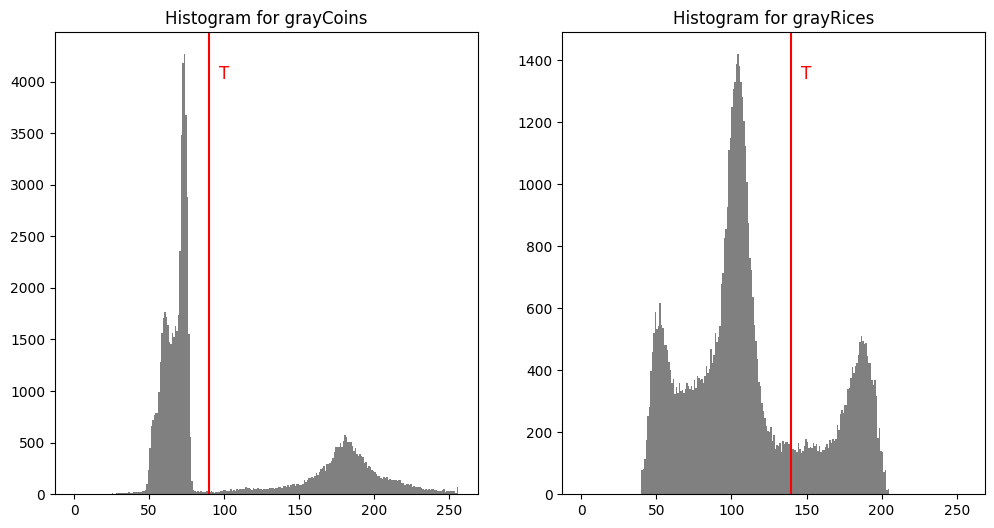

In [32]:
# Đọc ảnh
grayCoins = cv2.imread('IP/Image/coins.png',cv2.IMREAD_GRAYSCALE)
grayRices = cv2.imread('IP/Image/rice.png', cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.hist(grayCoins.ravel(), bins=256, range=[0, 256], color='gray')
plt.axvline(90, c='r')
plt.text(100, plt.ylim()[1] * 0.9, 'T', color='red', fontsize=12, ha='center')
plt.title('Histogram for grayCoins')

plt.subplot(122)
plt.hist(grayRices.ravel(), bins=256, range=[0, 256], color='gray')
plt.axvline(140, c='r')
plt.text(150, plt.ylim()[1] * 0.9, 'T', color='red', fontsize=12, ha='center')
plt.title('Histogram for grayRices')

plt.show()

In [34]:
print(grayCoins.shape)

(246, 300)


$\text{Theo quan sát từ biểu đồ trực quan, ta nhận thấy rằng ngưỡng thích hợp cho ảnh grayCoins là 90 và ảnh grayRices là 140}$

In [42]:
def apply_thresh(img, threshold):
    _, thresh1 = cv2.threshold(img, threshold, 255, cv2.THRESH_BINARY)
    _, thresh2 = cv2.threshold(img, threshold, 255, cv2.THRESH_BINARY_INV)
    _, thresh3 = cv2.threshold(img, threshold, 255, cv2.THRESH_TRUNC)
    _, thresh4 = cv2.threshold(img, threshold, 255, cv2.THRESH_TOZERO)
    _, thresh5 = cv2.threshold(img, threshold, 255, cv2.THRESH_TOZERO_INV)
    list_thresh = [img,thresh1,thresh2,thresh3,thresh4,thresh5]
    list_title = ["Original Image", "BINARY","BINARY_INV","TRUNC","TOZERO", "TOZERO_INV"]

    plt.figure(figsize = (12,6))
    for i in range (len(list_thresh)) :
        plt.subplot(2,3,i+1)
        plt.title(list_title[i])
        plt.imshow(list_thresh[i], cmap = 'gray'), plt.axis('off')
    plt.tight_layout()
    plt.show()
    

**Áp dụng ngưỡng 90 cho ảnh *grayCoins***

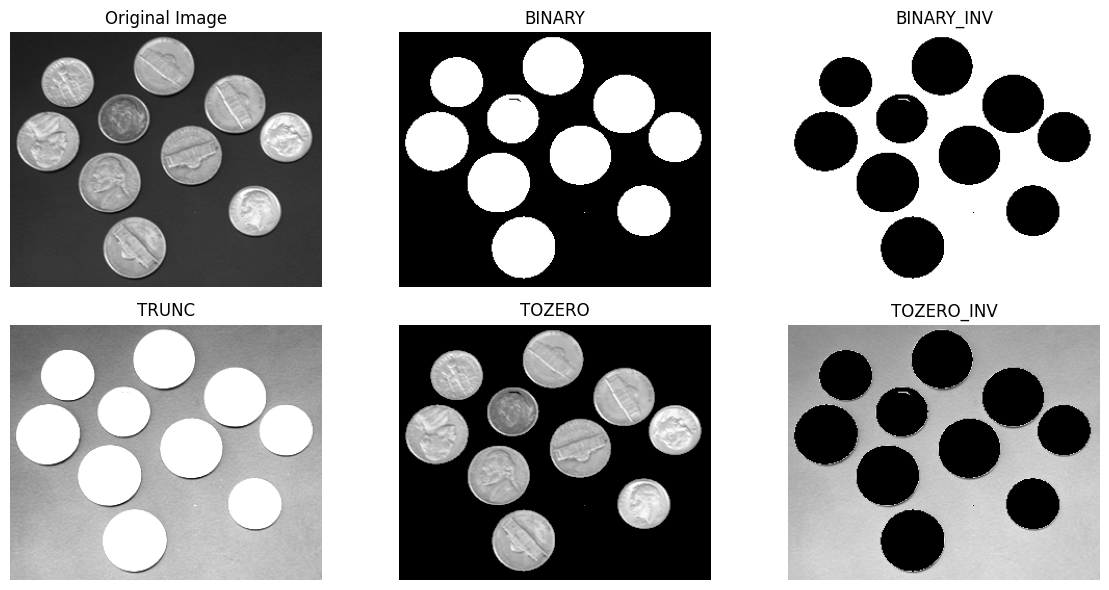

In [43]:
apply_thresh(grayCoins, 90)

**Áp dụng ngưỡng 140 cho ảnh *grayRices***

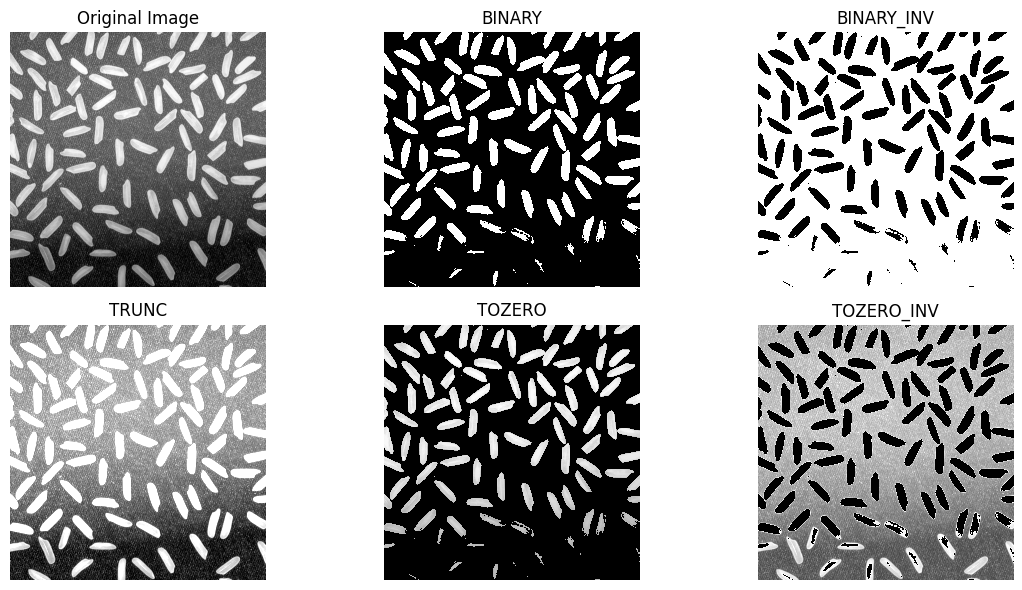

In [44]:
apply_thresh(grayRices,140)

- **Ex. 3.2 Read the image ‘adeverinta.jpg’ as grayscale and repeat the previous exercise. Comment on
the output.**

Text(0.5, 1.0, 'Histogram for prof_img')

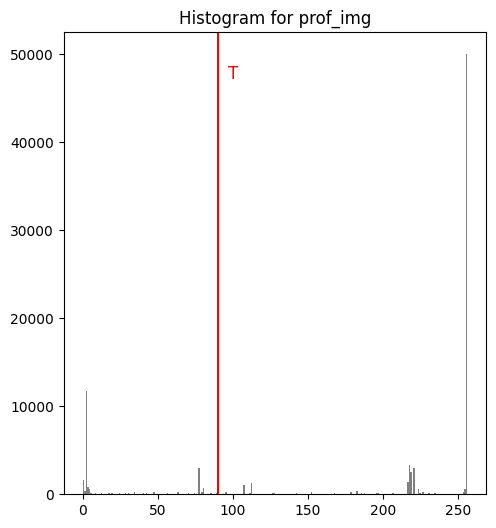

In [47]:
prof_img = cv2.imread('IP/Image/prof_baltazar.png',0)

plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.hist(prof_img.ravel(), bins=256, range=[0, 256], color='gray')
plt.axvline(90, c='r')
plt.text(100, plt.ylim()[1] * 0.9, 'T', color='red', fontsize=12, ha='center')
plt.title('Histogram for prof_img')


$\text{Theo quan sát thì ta có thể thấy được ngưỡng T là 90 sẽ thích hợp cho ảnh này}$

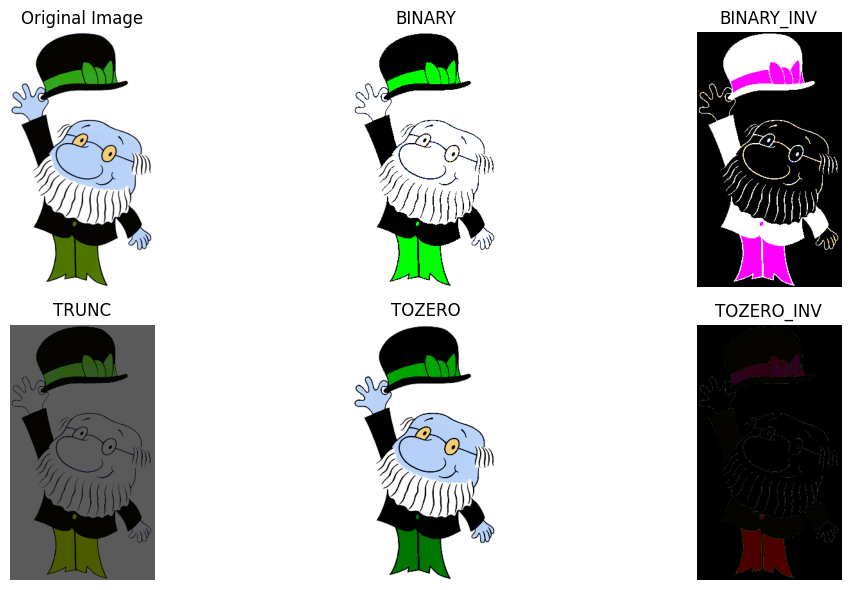

In [46]:
apply_thresh(prof_img, 90)

##### **3.1.1 Adaptive thresholding**

- **Ex. 3.3 Read the image ‘adeverinta.jpg’ as grayscale and apply adaptive thresholding (both options).
Compare the results with the ones from Ex. 3.2 and justify the outputs. The image has different lighting
conditions in different areas and a smoothing filter applied before using adaptive thresholding will
reduce the noise**

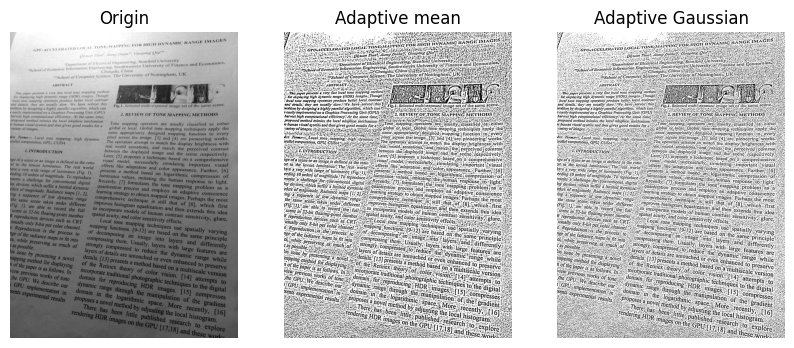

In [51]:
paper_img = cv2.imread('IP/Image/paper.png',0)

adap_mean = cv2.adaptiveThreshold(paper_img, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)
adap_gaussian = cv2.adaptiveThreshold(paper_img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

plt.figure(figsize = (10,6))
plt.subplot(1,3,1)
plt.title("Origin")
plt.imshow(paper_img, cmap = 'gray'), plt.axis('off')
plt.subplot(1,3,2)
plt.title("Adaptive mean")
plt.imshow(adap_mean, cmap = 'gray'), plt.axis('off')
plt.subplot(1,3,3)
plt.title("Adaptive Gaussian")
plt.imshow(adap_gaussian, cmap = 'gray'), plt.axis('off')
plt.show()

##### **3.1.2 Otsu’s thresholding**

- **Ex. 3.4 Read the images ‘rose.jpg’ and ‘yellowFl.jpg’ as grayscale and apply Otsu thresholding.
Compare the results with the previous methods. Experiment also with gaussian smoothing before the
Otsu binarization.**